# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Detect the Triple Bottom Pattern

In the previous units, you learnt how to identify and trade triple bottom pattern. In this unit, you will learn to programmatically identify the triple bottom pattern. In addition to this, you will also learn to define risk metrics for the triple bottom pattern.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Local Minima and Maxima](#lmm)
4. [Triple Bottom Scanner](#triple-bottom)
5. [Visualise the Triple Bottom Patterns](#visualise)
6. [Trade the Triple Bottom Pattern](#trade)
7. [Risk Management](#riskmanagement)
8. [Conclusion and Next Steps](#conclusion)


<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np
import datetime as datetime
from datetime import datetime

# For visualisation
import matplotlib.pyplot as plt
import mplfinance as mpf

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Import utility function
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import get_min_max

<a id='data'></a>
## Read the Data

Import the file `spy_daily_1993_2018.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for  SPDR S&P 500 ETF in the daily frequency. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/spy_daily_1993_2018.csv', index_col=0)

# Change the index type of data to datetime
data.index = pd.to_datetime(data.index)

# Print first 5 rows of the data
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
1993-01-29,25.352047,25.352047,25.225917,25.334028,1003200
1993-02-01,25.352036,25.514202,25.352036,25.514202,480500
1993-02-02,25.496201,25.586294,25.442146,25.568275,201300
1993-02-03,25.604306,25.856565,25.586288,25.838547,529400
1993-02-04,25.928646,26.000720,25.640350,25.946665,531500


<a id='lmm'></a>
## Local Minima and Maxima
Using `get_min_max()` function, calculate local minima and local maxima of `data` and store in the dataframes `minima_prices` and `maxima_prices` respectively.

In [3]:
# Use get_min_max() function to generate minima_prices and maxima_prices
minima_prices, maxima_prices = get_min_max(data, 5)

# Store values of both local minima and local maxima points in a sequential order in 'min_max' dataframe
min_max = pd.concat([minima_prices, maxima_prices]).sort_index()

min_max.tail()

Date
2018-10-11    252.627718
2018-10-29    242.807087
2018-11-08    262.775439
2018-11-23    245.815867
2018-12-03    262.009244
dtype: float64

<a id='triple-top'></a>
## Triple Bottom Scanner

Typically, the image shown below represents what an triple bottom pattern looks like.



<img src="https://d2a032ejo53cab.cloudfront.net/Glossary/8x6tjdr8/tb.JPG" width="500">

Next, to classify a sequence of 5 local minima and maxima points (such as A, B, C, D and E in above figure) as an triple bottom pattern, we need to check for some of the following conditions:

1. Points **B and D** must come under the set of local **maxima points**. This is because they represent the neckline of the triple bottom pattern.
<br>

2. Points **A, C and E** should lie in the set of local **minima points**, as they form the bottoms of the triple bottom pattern.
<br>

3. Points **A, C and E** must be less than  **B and D** to make sure the bottoms are below the neckline. 
<br>
 
4. The two points **A and C** (that form the first two bottoms) must not lie at a distance greater than 1.5% away from their mean. For example, if the average of **A and C** is 100, then the difference between **A and C** must not be greater than 1.5. The same goes for points C and E (that form the second and third bottoms) and also for points B and D (that form the neckline).


You can refer to the book on <a href='https://www.google.co.in/books/edition/Advanced_Trading_Rules/27Vo8RPc12wC?hl=en&gbpv=1&dq=patterns%5B%27IHS%27%5D&pg=PA53&printsec=frontcover
' target="_blank">Advanced Trading Rules</a> by Emmanual Acar and Stephen Satchell to get some deeper insights behind the conditions used to detect a triple bottom pattern.


### Create the Triple Bottom Scanner

Considering the above conditions, we can create a scanner as follows. It should be observed that the following function is similar to the head and shoulders, inverse head and shoulders, double top, double bottom, triple top scanner functions but with conditions listed above.

In [4]:
# Triple bottom scanner function
def tb_scanner(min_max, minima_prices, maxima_prices, frequency='daily'):

    # To store pattern instances
    patterns = []

    # Loop to iterate along the price data
    for i in range(5, len(min_max)):

        # Store 5 local minima and local maxima points at a time in the variable 'window'
        window = min_max.iloc[i-5:i]

        # Determine window length based on the frequency of data
        window_size = 1 + data.index.get_loc(window.index[-1]) - data.index.get_loc(window.index[0])        

        # Ensure that pattern is formed within 100 bars
        if window_size > 100:
            continue

        # Store the 5 unique points to check for conditions
        a, b, c, d, e = [window[i] for i in range(0, len(window))]

        # cond_1: To check b and d are in maxima_prices
        cond_1 = all(x in maxima_prices.values for x in [b, d])

        # cond_2: To check a,c,e are in minima_prices
        cond_2 = all(x in minima_prices.values for x in [a, c, e])

        # cond_3: To check if the bottoms are below the neckline
        cond_3 = (b > a) and (b > c) and (d > e) and (d > c)

        # cond_4: To check if A and C (and also C and E, B and D) are at a distance less than 1.5% away from their mean
        cond_4 = (abs(a-c) <= np.mean([a, c]) * 0.015) and (
            abs(c-e) <= np.mean([c, e]) * 0.015) and (abs(b-d) <= np.mean([b, d]) * 0.015)

        # Checking if all conditions are true
        if cond_1 and cond_2 and cond_3 and cond_4:

            # Append the pattern to list if all conditions are met
            patterns.append(
                ([window.index[i] for i in range(0, len(window))]))

    return patterns

In [5]:
# Detect triple bottom patterns and store the results
tb_patterns = tb_scanner(min_max, minima_prices, maxima_prices)

# Check the total instances of the pattern
len(tb_patterns)

22

This shows us that we have 22 instances of the triple bottom pattern in the SPDR S&P 500 ETF's price data since the year 1980. As of now, under `tb_patterns` we have the indices of each of the set of 5 sequential points that form the triple bottom pattern.

### Store the Pattern Details

To be able to take trades based on the triple bottom pattern, we will also require some additional information such as the dates and prices corresponding to the formation of the bottoms and neckline structures. Let us fetch all of this information and store it in a dataframe called `tb_patterns_data`.

In [6]:
# Initialise the dataframe and specify column names
tb_patterns_data = pd.DataFrame(tb_patterns)
tb_patterns_data.columns = [
    'bottom1_date', 'neck1_date', 'bottom2_date', 'neck2_date', 'bottom3_date']

# Populate the dataframe with relevant values
tb_patterns_data['bottom1_price'] = data.loc[tb_patterns_data.bottom1_date, 'Low'].values
tb_patterns_data['neck1_price'] = data.loc[tb_patterns_data.neck1_date, 'High'].values
tb_patterns_data['bottom2_price'] = data.loc[tb_patterns_data.bottom2_date, 'Low'].values
tb_patterns_data['neck2_price'] = data.loc[tb_patterns_data.neck2_date, 'High'].values
tb_patterns_data['bottom3_price'] = data.loc[tb_patterns_data.bottom3_date, 'Low'].values

# Display the pattern details for each instance
tb_patterns_data.tail()

,bottom1_date,neck1_date,bottom2_date,neck2_date,bottom3_date,bottom1_price,neck1_price,bottom2_price,neck2_price,bottom3_price
17,2015-03-26,2015-04-15,2015-04-17,2015-04-27,2015-05-06,177.932361,183.964587,180.451607,185.219794,180.233661
18,2015-06-09,2015-06-22,2015-07-07,2015-07-20,2015-07-27,181.044388,186.217163,178.789133,186.733906,180.672454
19,2015-07-07,2015-07-20,2015-07-27,2015-07-31,2015-08-12,178.789133,186.733906,180.672454,185.218543,179.884079
20,2016-04-07,2016-04-20,2016-05-06,2016-05-11,2016-05-19,180.812506,187.783649,181.515860,185.664686,180.536561
21,2017-03-09,2017-03-15,2017-03-27,2017-04-05,2017-04-13,213.288020,216.635644,210.463001,215.715279,211.280762


<a id='visualise'></a>
## Visualise the Triple Bottom Pattern

In the upcoming cells, we will perform some simple steps in order to visualise the triple bottom pattern using the `mplfinance` library. We have multiple instance of the triple bottom pattern, but, for now let us plot one pattern at a time.

### Specify the Pattern to Plot

In the below cell, we have set the `pattern_index` as `-1` since we want to plot the most recent pattern. However, feel free to change this value if you wish to plot a different triple bottom instance.

In [7]:
# Specify the pattern index
pattern_index = -1

# Initialise the pattern data
tb_patterns_to_plot = tb_patterns_data.iloc[pattern_index]
points = int(len(tb_patterns_to_plot)/2)

# Capture the pattern details for the most recent pattern
tb = pd.DataFrame()
tb['dates'] = tb_patterns_to_plot.iloc[:points]
tb['price'] = tb_patterns_to_plot.iloc[points:].values
tb

,dates,price
bottom1_date,2017-03-09 00:00:00,213.28802
neck1_date,2017-03-15 00:00:00,216.635644
bottom2_date,2017-03-27 00:00:00,210.463001
neck2_date,2017-04-05 00:00:00,215.715279
bottom3_date,2017-04-13 00:00:00,211.280762


### Get the OHLCV Data Corresponding to the Pattern

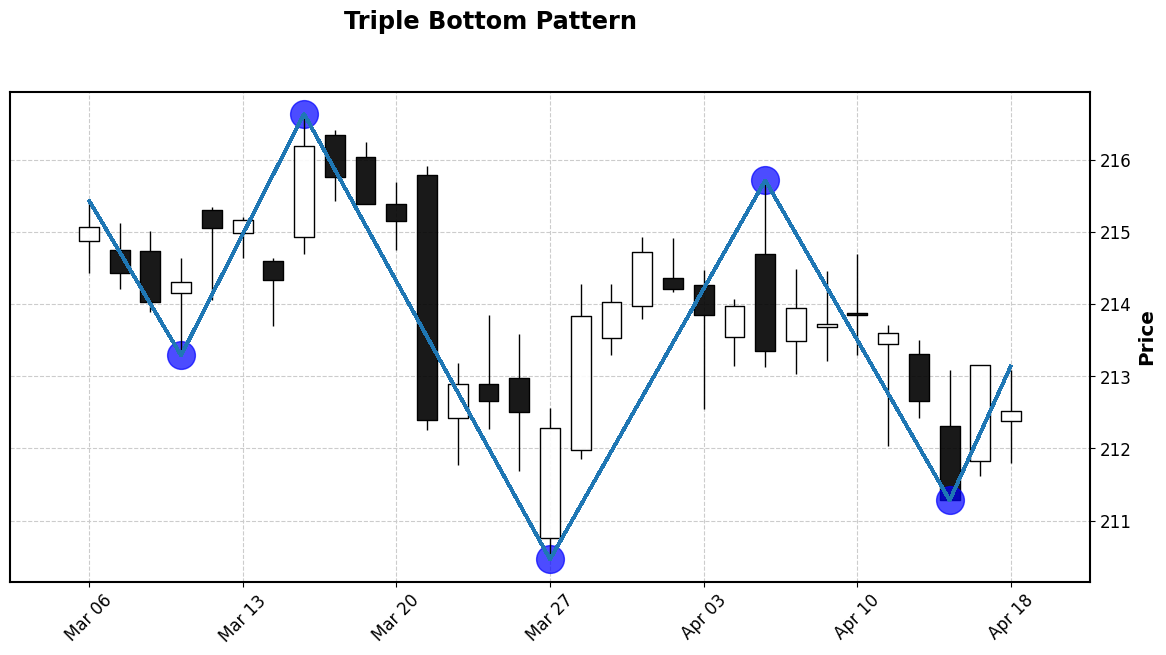

In [8]:
# Initialise the start and end dates for OHLCV data
start_index = data.index.get_loc(tb.dates[0]) - 3
last_index = data.index.get_loc(tb.dates[-1]) + 3

# Fetch the OHLCV data for the period
data_to_plot = data.iloc[start_index:last_index]

# Add pattern details to data_to_plot
data_to_plot['pattern'] = np.nan
data_to_plot.loc[tb.dates, 'pattern'] = tb.price.values

# Define scatter plot to mark the 5 sequential points forming the pattern
tb_plot = mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                           panel=0, color="blue", alpha=0.7)

# Define subplot of a line that will connect the 5 sequential points
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(tb.dates[0])].max()['High'])]+list(tb.itertuples(
    index=False, name=None)) + [(data_to_plot.index[-1], data.iloc[data.index.get_loc(tb.dates[-1]):last_index].max()['High'])]

# Plot the candlestick chart along with pattern related subplots
mpf.plot(data_to_plot, type='candle', style='classic', addplot=tb_plot,
         title='Triple Bottom Pattern', figsize=(15, 7), alines=pattern_line)

<a id='trade'></a>
## Trade the Triple Bottom Pattern

Find the long entry date of the triple bottom pattern and store it in the column `confirmation_date` of `tb_patterns_data`

In [9]:
# Function to calculate the long entry date of the triple bottom pattern
def get_confirmation_date(tb_patterns, data=data):

    # store the data after third bottom in 'data_after_bottom3'
    data_after_bottom3 = data.loc[tb_patterns.bottom3_date:]['Close']

    try:
        # return the long entry date if price went above the neckline
        return data_after_bottom3[data_after_bottom3 > tb_patterns.neck2_price].index[0]

    except:
        # return NaN if price never went above the neckline
        return np.nan

# Create the column 'confirmation_date' to store the long entry dates calculated using the function get_confirmation_date()
tb_patterns_data['confirmation_date'] = tb_patterns_data.apply(
    get_confirmation_date, axis=1)

For efficient trading scenario:
1) The `time_for_confirmation` must be more than 5 bars away to avoid look-ahead bias<br>
This ensures that trades are not taken before the pattern is completely formed.

2) The `time_for_confirmation` must occur within 30 bars<br>
This ensures that the pattern is not occurring over an excessively long duration, as generally such patterns would not qualify as good triple bottom patterns. 

The result is a subset of the data that meets both conditions and represents valid triple bottom patterns where we can take trades.

In [10]:
# Drop NaN values from 'tb_patterns_data'
tb_patterns_data.dropna(inplace=True)

# Store the number of days taken to generate long entry date in the column 'time_for_confirmation'
bottom3_date_indices = data.index.get_indexer(tb_patterns_data['bottom3_date'])
confirmation_date_indices = data.index.get_indexer(tb_patterns_data['confirmation_date'])
tb_patterns_data['time_for_confirmation'] = 1 - bottom3_date_indices + confirmation_date_indices

# Selecting the patterns that generated long entry within 30 days of forming the third bottom
tb_patterns_data = tb_patterns_data[(tb_patterns_data['time_for_confirmation'] > 5) & (tb_patterns_data['time_for_confirmation'] < 30)]

# Create'signal' column with values as '1' since we are buying once the pattern is confirmed
tb_patterns_data['signal'] = 1

tb_patterns_data.tail()

,bottom1_date,neck1_date,bottom2_date,neck2_date,bottom3_date,bottom1_price,neck1_price,bottom2_price,neck2_price,bottom3_price,confirmation_date,time_for_confirmation,signal
11,2007-05-24,2007-06-01,2007-06-07,2007-06-15,2007-06-27,111.199020,113.898995,109.959713,113.841619,109.692826,2007-07-12,11,1
14,2014-03-14,2014-03-21,2014-03-27,2014-04-04,2014-04-11,156.995078,161.603668,157.226256,162.185033,155.011934,2014-05-12,21,1
15,2014-04-28,2014-05-02,2014-05-07,2014-05-13,2014-05-15,158.132535,161.706236,159.030207,162.800560,159.432040,2014-05-27,8,1
17,2015-03-26,2015-04-15,2015-04-17,2015-04-27,2015-05-06,177.932361,183.964587,180.451607,185.219794,180.233661,2015-05-18,9,1
21,2017-03-09,2017-03-15,2017-03-27,2017-04-05,2017-04-13,213.288020,216.635644,210.463001,215.715279,211.280762,2017-04-25,8,1


### Plot the Pattern Along With the Long Entry Date

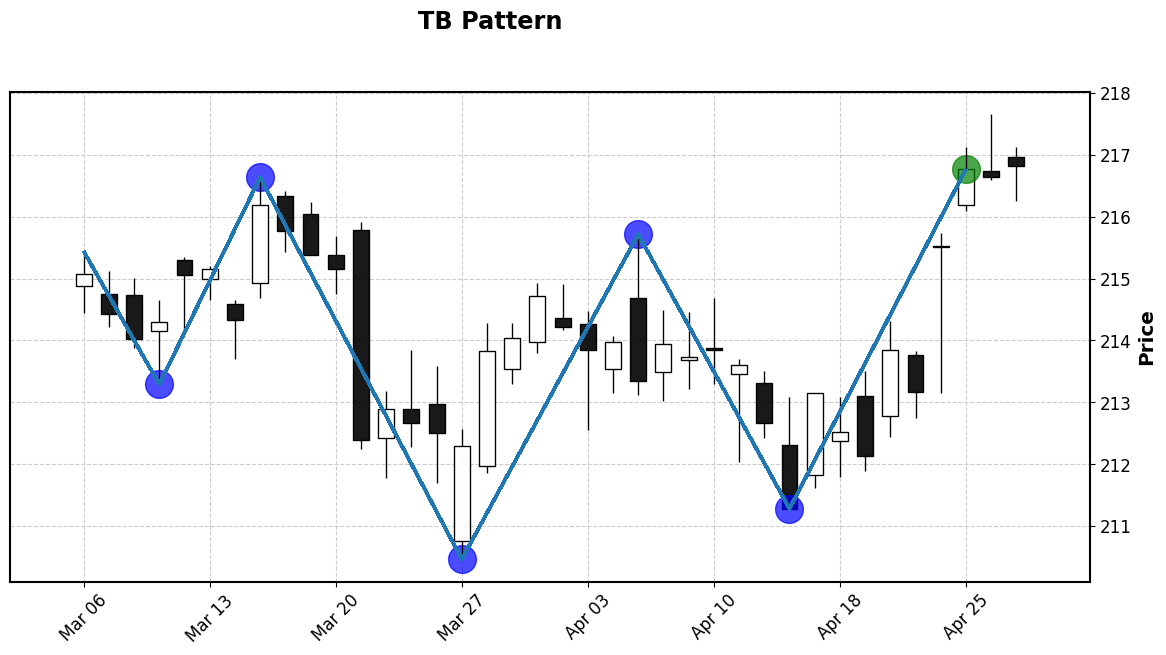

In [11]:
# Select the pattern data
tb_patterns_to_plot = tb_patterns_data.iloc[pattern_index]

# Capture the pattern details for the most recent pattern
tb = pd.DataFrame()
tb['dates'] = tb_patterns_to_plot.iloc[:points]
tb['price'] = tb_patterns_to_plot.iloc[points:2*points].values

# Define the start and end date of the pattern to plot
start_index = data.index.get_loc(tb_patterns_to_plot.bottom1_date) - 3
last_index = data.index.get_loc(tb_patterns_to_plot.confirmation_date) + 3

# Select the data of pattern to plot
data_to_plot = data.iloc[start_index:last_index]
data_to_plot['pattern'] = np.nan

data_to_plot.loc[tb_patterns_to_plot.values[:5],
                 'pattern'] = tb_patterns_to_plot[5:10].values

# Define 'pattern_line' to draw the pattern
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(tb.dates[0])].max()['High'])] + list(tb.itertuples(index=False, name=None)) \
    + [(tb_patterns_to_plot.confirmation_date,
        data.loc[tb_patterns_to_plot.confirmation_date].Close)]

# Define list of markets and store in 'tb_plot'
tb_plot = [mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                            panel=0, color="blue", alpha=0.7)]
data_to_plot['trade'] = np.nan
data_to_plot.loc[tb_patterns_to_plot.confirmation_date,
                 'trade'] = data_to_plot.loc[tb_patterns_to_plot.confirmation_date, 'Close']
tb_plot += [mpf.make_addplot(data_to_plot.trade, type='scatter', marker='o', markersize=400,
                             panel=0, color="green", alpha=0.7)]

# Plot the candlestick plot of line plot and markets representing the selected pattern
mpf.plot(data_to_plot, type='candle', style='classic', addplot=tb_plot,
         title='TB Pattern', figsize=(15, 7), alines=pattern_line)

<a id='riskmanagement'></a>
## Risk Management

Define a stop-loss 1% below the third bottom and profit target at a distance of 'bottom_length' from the long entry price

In [12]:
# Stop-loss 1% below second bottom
tb_patterns_data['stoploss'] = tb_patterns_data['bottom3_price']*0.99

# Calculate the bottom length and store it in the column 'bottom_length'
tb_patterns_data['bottom_length'] = tb_patterns_data['neck2_price'] - \
    tb_patterns_data['bottom3_price']

# Calculate profit target and store it in the column 'target'
tb_patterns_data['target'] = tb_patterns_data['neck2_price'] + \
    1 * tb_patterns_data['bottom_length']

tb_patterns_data.tail()

,bottom1_date,neck1_date,bottom2_date,neck2_date,bottom3_date,bottom1_price,neck1_price,bottom2_price,neck2_price,bottom3_price,confirmation_date,time_for_confirmation,signal,stoploss,bottom_length,target
11,2007-05-24,2007-06-01,2007-06-07,2007-06-15,2007-06-27,111.199020,113.898995,109.959713,113.841619,109.692826,2007-07-12,11,1,108.595897,4.148794,117.990413
14,2014-03-14,2014-03-21,2014-03-27,2014-04-04,2014-04-11,156.995078,161.603668,157.226256,162.185033,155.011934,2014-05-12,21,1,153.461815,7.173099,169.358133
15,2014-04-28,2014-05-02,2014-05-07,2014-05-13,2014-05-15,158.132535,161.706236,159.030207,162.800560,159.432040,2014-05-27,8,1,157.837720,3.368519,166.169079
17,2015-03-26,2015-04-15,2015-04-17,2015-04-27,2015-05-06,177.932361,183.964587,180.451607,185.219794,180.233661,2015-05-18,9,1,178.431324,4.986134,190.205928
21,2017-03-09,2017-03-15,2017-03-27,2017-04-05,2017-04-13,213.288020,216.635644,210.463001,215.715279,211.280762,2017-04-25,8,1,209.167954,4.434517,220.149795


### Plot the Pattern Along With Stop-Loss and Take-Profit Levels

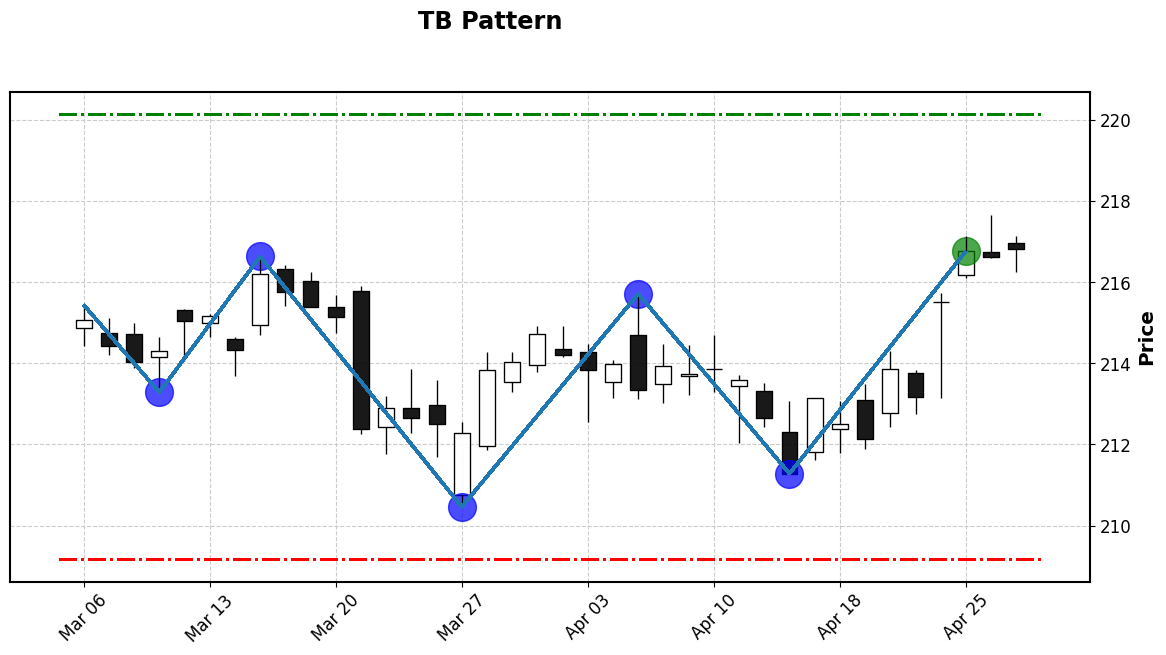

In [13]:
# Select the pattern to plot
tb_patterns_to_plot = tb_patterns_data.iloc[pattern_index]

# Plot the candlestick plot of pattern along with stop-loss and profit target
mpf.plot(data_to_plot, type='candle', style='classic', addplot=tb_plot,
         title='TB Pattern', figsize=(15, 7), alines=pattern_line,
         hlines=dict(hlines=[tb_patterns_to_plot.target, tb_patterns_to_plot.stoploss],
                     colors=['g', 'r'], linestyle='-.'))

As you can see in the above plot, you have successfully identified a triple bottom pattern based on the OHLCV data and defined its stop-loss and profit target to trade. 

<a id='conclusion'></a>
## Conclusion and Next Steps
In this notebook, you have learnt to scan for triple bottom patterns and generate exit parameters for the same. You can use these exit parameters to backtest to understand the performance of the strategy.
<br><br>